In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
data = pd.read_csv('Unemployment in India.csv')

In [44]:
data

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [46]:
data.shape

(768, 7)

In [47]:
data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [48]:
data.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [49]:
data.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [50]:
data.duplicated().sum()

np.int64(27)

In [51]:
data.columns = data.columns.str.strip()
print(data.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [52]:
data.columns = ['Region','Date','Frequency','Unemployment_Rate','Employed','Labour_Participation','Area']

In [53]:
data.dtypes

Region                   object
Date                     object
Frequency                object
Unemployment_Rate       float64
Employed                float64
Labour_Participation    float64
Area                     object
dtype: object

In [54]:
data = data.dropna()

In [55]:
data.isnull().sum()

Region                  0
Date                    0
Frequency               0
Unemployment_Rate       0
Employed                0
Labour_Participation    0
Area                    0
dtype: int64

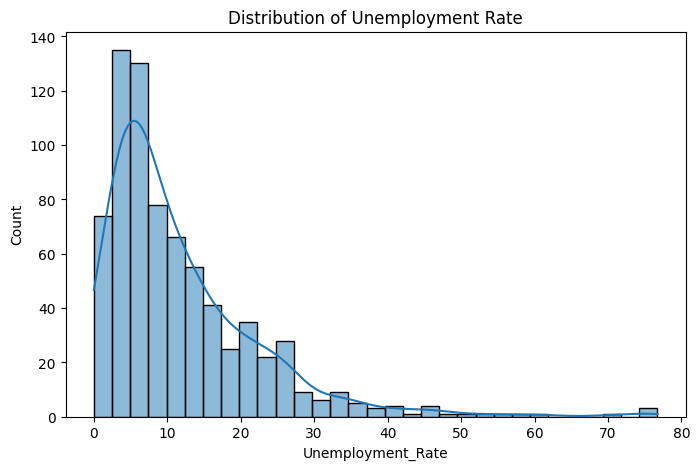

In [56]:
plt.figure(figsize=(8,5))
sns.histplot(data['Unemployment_Rate'], kde=True)
plt.title("Distribution of Unemployment Rate")
plt.show()

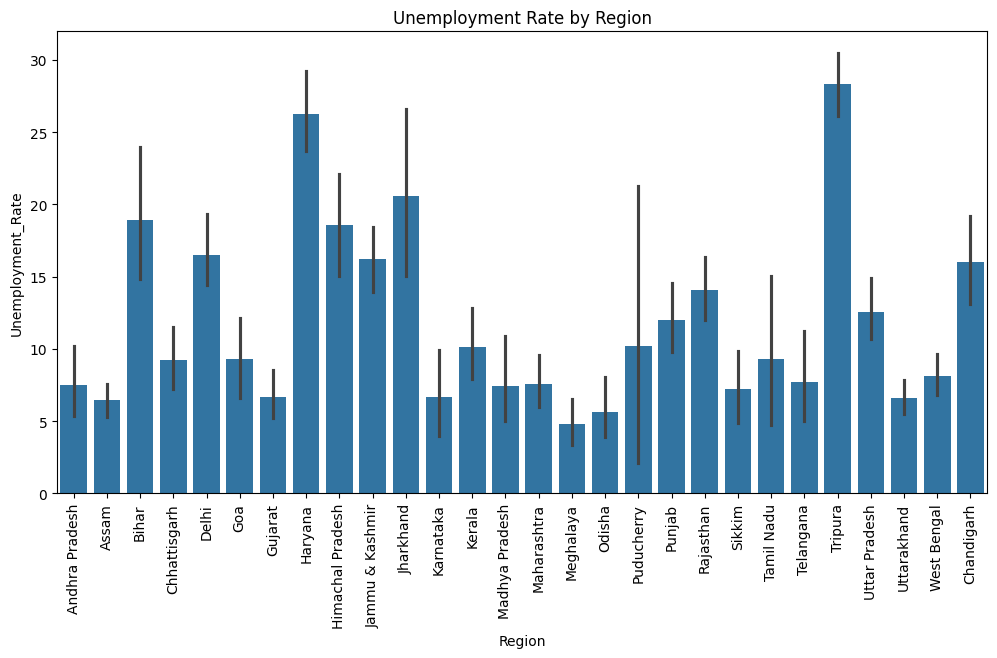

In [57]:
plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='Unemployment_Rate', data=data)
plt.xticks(rotation=90)
plt.title("Unemployment Rate by Region")
plt.show()

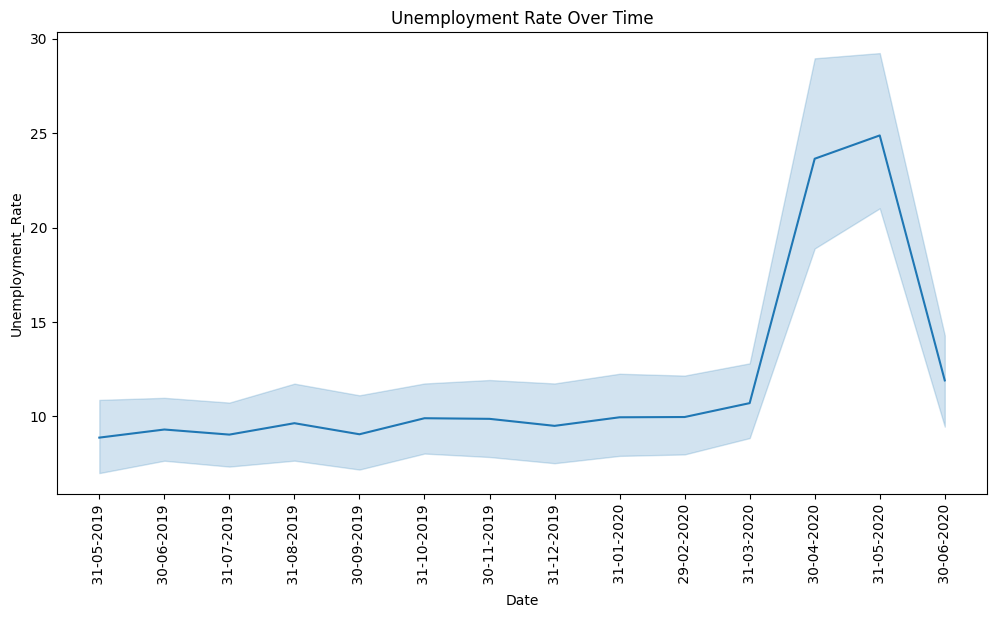

In [58]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='Unemployment_Rate', data=data)
plt.xticks(rotation=90)
plt.title("Unemployment Rate Over Time")
plt.show()

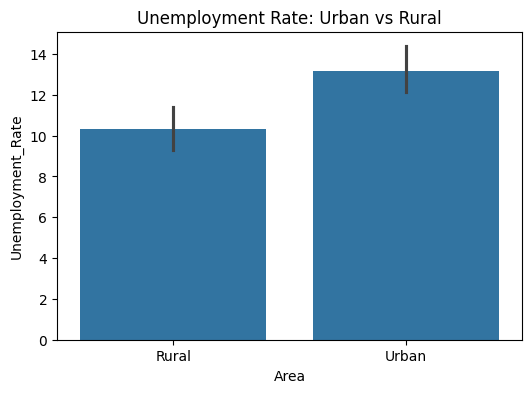

In [59]:
plt.figure(figsize=(6,4))
sns.barplot(x='Area', y='Unemployment_Rate', data=data)
plt.title("Unemployment Rate: Urban vs Rural")
plt.show()

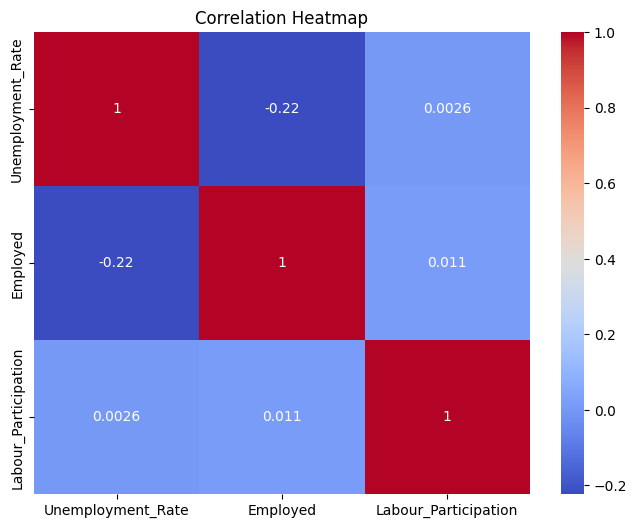

In [60]:
plt.figure(figsize=(8,6))
sns.heatmap(data[['Unemployment_Rate','Employed','Labour_Participation']].corr(), 
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [61]:
X = data[['Employed','Labour_Participation']]
y = data['Unemployment_Rate']

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression R2 Score:", r2_score(y_test, lr_pred))

Linear Regression R2 Score: 0.03938840314253944


In [68]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, rf_pred))

Random Forest R2 Score: 0.3668914327728341


In [69]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree R2 Score:", r2_score(y_test, dt_pred))

Decision Tree R2 Score: 0.1754911947796325


In [67]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
predictions = model.predict(X_test)

In [65]:
from sklearn.metrics import r2_score
print("Model Accuracy:", r2_score(y_test, predictions))

Model Accuracy: 0.03938840314253944


In [70]:
print("Linear Regression:", r2_score(y_test, lr_pred))
print("Random Forest:", r2_score(y_test, rf_pred))
print("Decision Tree:", r2_score(y_test, dt_pred))

Linear Regression: 0.03938840314253944
Random Forest: 0.3668914327728341
Decision Tree: 0.1754911947796325


In [78]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

best_model = RandomForestRegressor(n_estimators=100, random_state=42)

best_model.fit(x_train_scaled, y_train)

y_final = best_model.predict(x_test_scaled)

print("Final R2 Score:", r2_score(y_test, y_final))

Final R2 Score: 0.36677576927545663


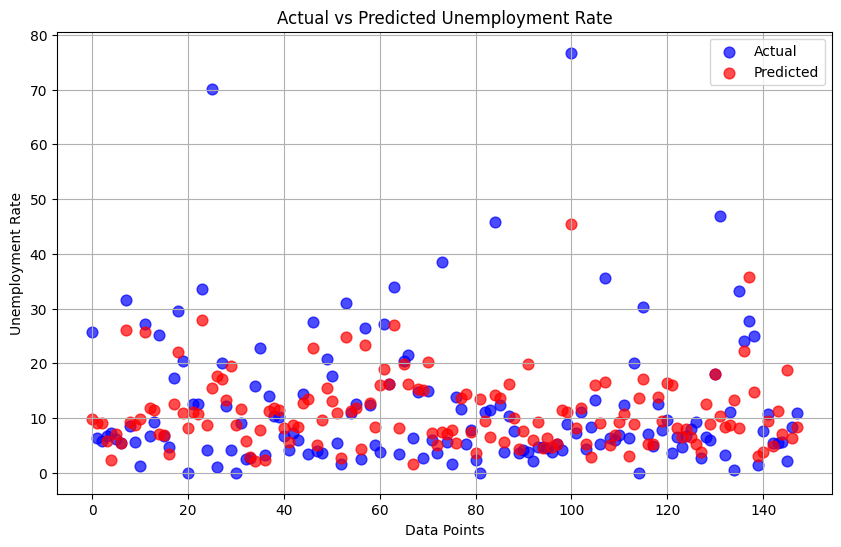

In [80]:
plt.figure(figsize=(10,6))

plt.scatter(range(len(y_test)), y_test, 
            color='blue', s=60, alpha=0.7, label='Actual')

plt.scatter(range(len(y_final)), y_final, 
            color='red', s=60, alpha=0.7, label='Predicted')

plt.xlabel("Data Points")
plt.ylabel("Unemployment Rate")
plt.title("Actual vs Predicted Unemployment Rate")

plt.legend()
plt.grid(True)

plt.show()